In [ ]:
import sys

import os

import h5py

from astropy.io import fits

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from mrileyowens.stats import weighted_quantile

In [ ]:
def compare():

    # Establish common directories
    home = os.getcwd()
    data = f'{home}/data'
    figs = f'{home}/figs'
    results = f'{home}/results'

    catalog = f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits'
    hdul_endsley2024 = fits.open(catalog)

    ids_endsley2024 = hdul_endsley2024[1].data['ID']

    # Set the prefixes of the two sets of fits that this work made (one with and one without Lya but otherwise identical)
    names = ['JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits', 'JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits_no_lya']

    m_uv_bins = ['bright', 'faint', 'vfaint']

    # Set the labels for the legends of the figure
    labels_markers = ['with Lya', 'no Lya']

    # Set the colors of the markers for the two sets of fits
    colors = ['orange', 'blue']

    fig, ax = plt.subplots()
    fig_err, ax_err = plt.subplots()

    for i, name in enumerate(names):

        for j, m_uv_bin in enumerate(m_uv_bins):

            with h5py.File(f'{results}/ew/{name}_ews_{m_uv_bin}.h5', 'r') as f:

                for k, id in enumerate(list(f.keys())):

                    ew_posterior_me = f[id]['h_beta_ews'][:] + f[id]['o_iii_ews'][:]
                    probs = f[id]['probabilities'][:]

                    ew_me, ew_lower, ew_upper = weighted_quantile(ew_posterior_me, probs, [0.5, 0.16, 0.84])

                    ew_endsley2024, ew_endsley2024_lower, ew_endsley2024_upper = hdul_endsley2024[1].data['OIIIHbEw'][ids_endsley2024 == id][0], hdul_endsley2024[1].data['OIIIHbEw_l16'][ids_endsley2024 == id][0], hdul_endsley2024[1].data['OIIIHbEw_u84'][ids_endsley2024 == id][0]

                    ax.errorbar(ew_me, ew_endsley2024, xerr=[[ew_me - ew_lower], [ew_upper - ew_me]], yerr=[[ew_endsley2024 - ew_endsley2024_lower], [ew_endsley2024_upper - ew_endsley2024]], color=colors[i], label=f'{labels_markers[i] if j == 0 and k == 0 else ''}', alpha=0.5)
                
                    ax_err.scatter(ew_upper - ew_lower, ew_endsley2024_upper - ew_endsley2024_lower, color=colors[i], label=f'{labels_markers[i] if j == 0 and k == 0 else ''}', alpha=0.5)
                
    ax.set_xlabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Me)')
    ax.set_ylabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Endsley et al. (2024))')

    ax_err.set_xlabel('log$_{10}$((P$_{84}$(EW) - P$_{16}$(EW)) / $\AA$) (Me)')
    ax_err.set_ylabel('log$_{10}$((P$_{84}$(EW) - P$_{16}$(EW)) / $\AA$) (Endsley et al. (2024))')

    # Create a one-to-one line on the figures
    ax.axline((1000,1000), slope=1, color='red', linestyle='dashed')
    ax_err.axline((1000,1000), slope=1, color='red', linestyle='dashed')

    ax.loglog()
    ax_err.loglog()

    fig.savefig(f'{figs}/compare_ew.png', dpi=200, bbox_inches='tight')
    fig_err.savefig(f'{figs}/compare_ew_errors.png', dpi=200, bbox_inches='tight')

<>:35: SyntaxWarning: invalid escape sequence '\A'
<>:36: SyntaxWarning: invalid escape sequence '\A'
<>:38: SyntaxWarning: invalid escape sequence '\A'
<>:39: SyntaxWarning: invalid escape sequence '\A'
<>:35: SyntaxWarning: invalid escape sequence '\A'
<>:36: SyntaxWarning: invalid escape sequence '\A'
<>:38: SyntaxWarning: invalid escape sequence '\A'
<>:39: SyntaxWarning: invalid escape sequence '\A'
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_84523/2632690519.py:35: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Me)')
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_84523/2632690519.py:36: SyntaxWarning: invalid escape sequence '\A'
  ax.set_ylabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Endsley et al. (2024))')
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_84523/2632690519.py:38: SyntaxWarning: invalid escape sequence '\A'
  ax_err.set_xlabel('log$_{10}$((P$_{84}$(EW) - P$_{16}$

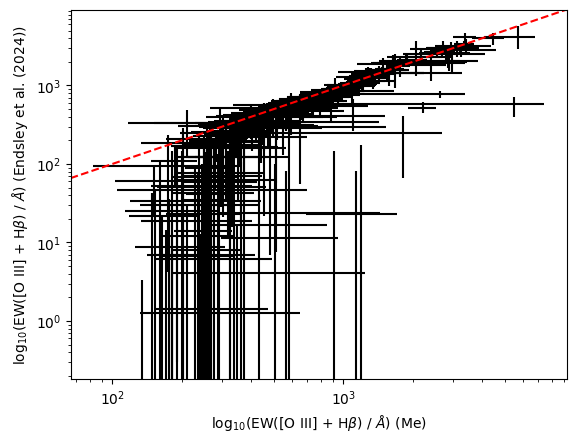

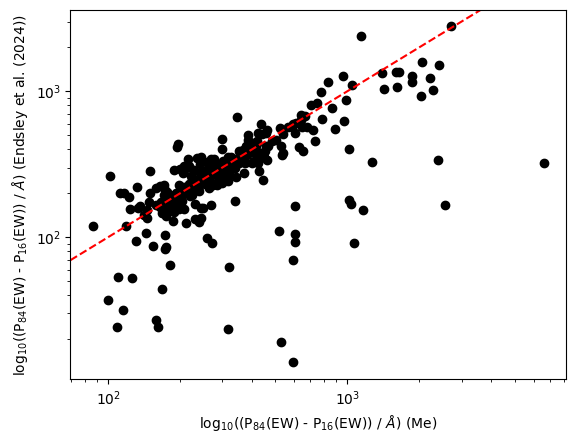

In [9]:
compare()